In [1]:
from tqdm import trange
import matplotlib.pyplot as plt
from mlserve_sdk.client import MLServeClient
import os
from dotenv import load_dotenv
import numpy as np

load_dotenv()

True

In [2]:
# --- Synthetic marketing environment ---
class MarketingEnvironment:
    def __init__(self, n_features=5, n_actions=3):
        # Each action has its own "true" weight vector that determines success probability
        self.n_features = n_features
        self.n_actions = n_actions
        self.action_weights = np.random.randn(n_actions, n_features)
        self.base_probs = np.array([0.2, 0.4, 0.9])  # baseline conversion rates

    def step(self, user_features, action):
        """
        Given a user's feature vector and a chosen action,
        compute the probability of conversion and return a binary reward.
        """
        linear_term = np.dot(self.action_weights[action], user_features)
        # ✅ Prevent overflow in exp
        linear_term = np.clip(linear_term, -200, 200)

        p = 1 / (1 + np.exp(-linear_term))  # sigmoid
        true_prob = 0.3 * p + 0.7 * self.base_probs[action]
        return 1 if np.random.rand() < true_prob else 0

In [3]:
USERNAME = os.getenv("USERNAME")
TOKEN = os.getenv("TOKEN")

client = MLServeClient()
client.login(USERNAME, TOKEN)

In [6]:
# 1️⃣ Configure an RL model (numerical-only)
feature_contract = {
    "features": [
        {"name": "age", "type": "continuous"},
        {"name": "income", "type": "continuous"},
        {"name": "loyalty_score", "type": "continuous"}
    ],
    "actions": ["show_discount", "show_premium", "no_action"]
}

resp = client.configure_online_model(
    name="promo-policy",
    version="v1",
    task_type="policy_next",
    feature_contract=feature_contract
)
print("✅ Model Configured:")
print(resp)

deployment_id = resp["deployment_id"]
print("🚀 Deployment started:", deployment_id)

# Step 2️⃣ — Poll until deployment finishes
final_status = client.wait_for_deployment(deployment_id)
print("✅ Final deployment status:", final_status)

✅ Final deployment status: {'deployment_id': 3, 'model_name': 'promo-policy', 'version': 'v1', 'status': 'success', 'logs': 'Building Docker image...\n✅ Image built successfully. Starting container...\n🚀 Container deployed successfully.', 'created_at': '2025-10-30T21:09:46.151178+00:00', 'predict_url': 'https://mlserve.com/api/v1/online_predict/promo-policy/v1', 'feedback_url': 'https://mlserve.com/api/v1/online_feedback/promo-policy/v1'}


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [07:07<00:00,  4.68it/s]


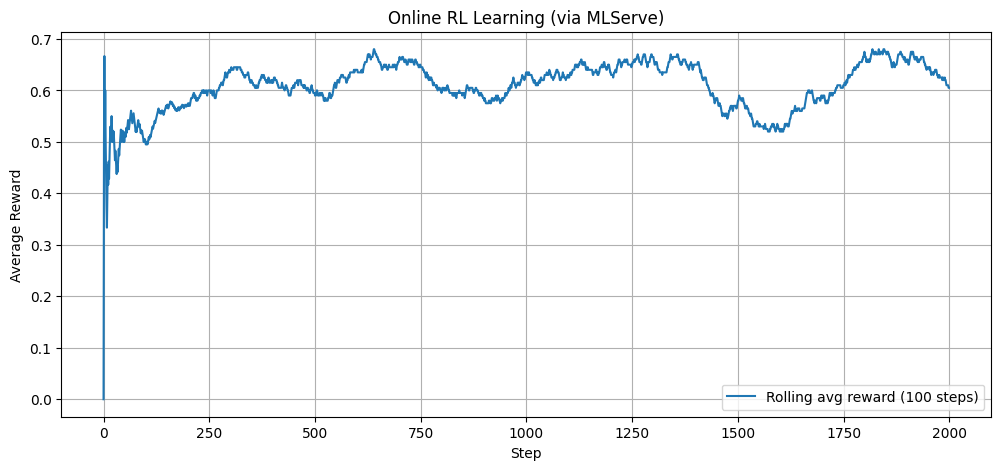

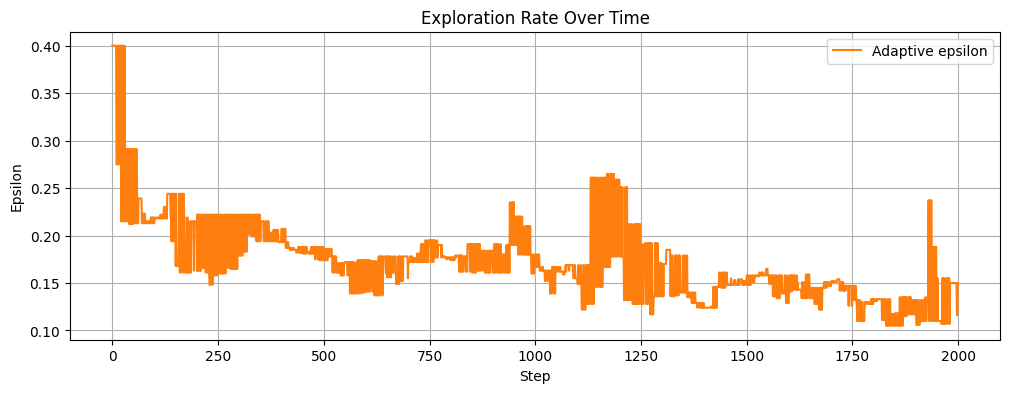

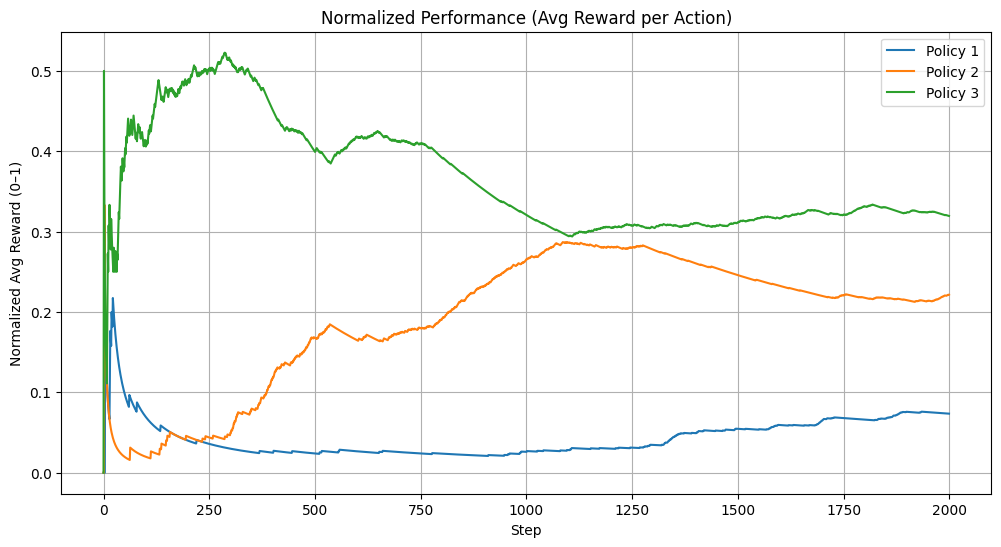

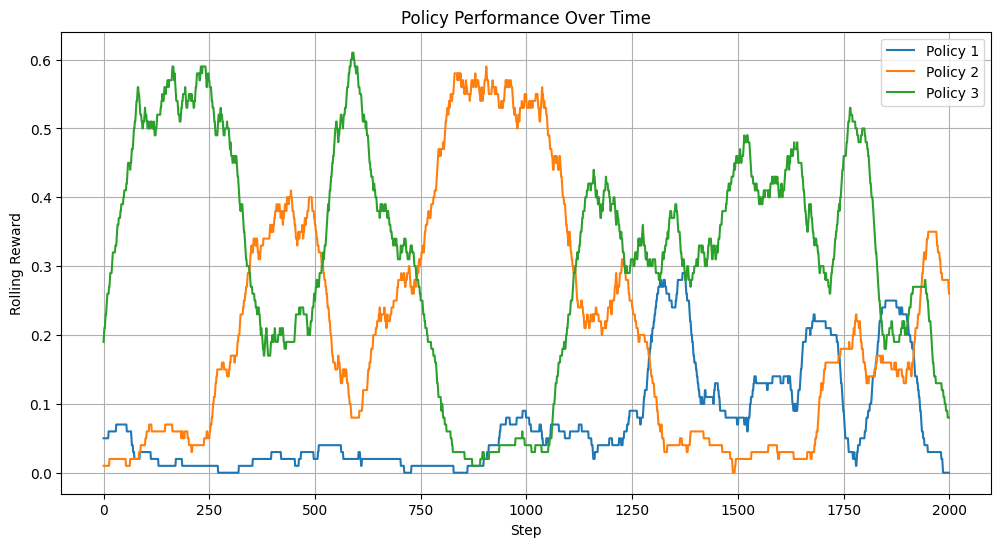

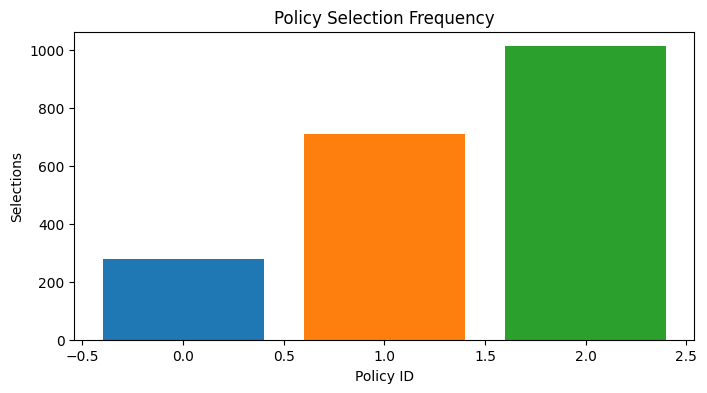

In [7]:
# --- 🔹 Simulation config ---
model_name = "promo-policy"
model_version = "v1"
BATCH_FEEDBACK_SIZE = 10  # number of feedbacks per batch

n_features = 3
n_steps = 2000
n_policies = 3

env = MarketingEnvironment(n_features=n_features, n_actions=3)

rewards = []
avg_rewards = []
epsilons = []
policy_choices = []
policy_rewards = np.zeros((n_policies, n_steps))

# 🔸 feedback buffer
feedback_buffer = []
actions_map = {"show_discount": 0, "show_premium": 1, "no_action": 2}

# --- 🔹 Run the online RL loop ---
for t in trange(n_steps):
    # 1️⃣ Simulate user context
    user_features = {
        "age": np.random.randint(18, 65),
        "income": np.random.uniform(20000, 100000),
        "loyalty_score": np.random.uniform(0, 1),
    }

    # 2️⃣ Get action from RL model (online_predict)
    try:
        pred = client.online_predict(
            name=model_name,
            version=model_version,
            inputs=[user_features]
        )
        res = pred["predictions"][0]
        action_name = res["action"]
        policy_id = res["policy_id"]
        epsilon = res["epsilon"]
        mode = res["mode"]
    except Exception as e:
        print(f"Prediction failed at step {t}: {e}")
        continue

    # 3️⃣ Map action -> index and simulate environment reward
    action_idx = actions_map[action_name]
    reward = env.step(list(user_features.values()), action_idx)

    # 4️⃣ Buffer feedback
    feedback_buffer.append({
        "features": user_features,
        "action": action_name,
        "reward": reward,
        "policy_id": policy_id
    })

    # 🔁 Send feedback in batches
    if len(feedback_buffer) >= BATCH_FEEDBACK_SIZE or t == n_steps - 1:
        try:
            client.online_feedback(model_name, model_version, feedback_buffer)
            feedback_buffer.clear()
        except Exception as e:
            print(f"Feedback batch failed at step {t}: {e}")

    # 5️⃣ Logging
    rewards.append(reward)
    avg_rewards.append(np.mean(rewards[-200:]))
    epsilons.append(epsilon)
    policy_choices.append(policy_id)
    policy_rewards[policy_id, t] = reward

# --- 🔹 Visualization ---
window = 100

# --- 🔹 Normalized performance (average reward per action) ---
normalized_performance = np.zeros((n_policies, n_steps))
max_reward = np.max(rewards) if rewards else 1  # prevent division by zero

for i in range(n_policies):
    # Compute cumulative average reward for each policy up to time t
    rewards_i = policy_rewards[i]
    cum_sum = np.cumsum(rewards_i)
    counts = np.arange(1, n_steps + 1)
    avg_per_action = np.divide(cum_sum, counts, where=counts != 0)
    normalized_performance[i] = avg_per_action / max_reward

# Rolling average reward
plt.figure(figsize=(12, 5))
plt.plot(avg_rewards, label=f"Rolling avg reward ({window} steps)", color="C0")
plt.title("Online RL Learning (via MLServe)")
plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.legend()
plt.grid(True)
plt.show()

# Epsilon decay
plt.figure(figsize=(12, 4))
plt.plot(epsilons, label="Adaptive epsilon", color="C1")
plt.title("Exploration Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Epsilon")
plt.legend()
plt.grid(True)
plt.show()

# Plot normalized performance
plt.figure(figsize=(12, 6))
for i in range(n_policies):
    plt.plot(normalized_performance[i], label=f"Policy {i+1}")
plt.title("Normalized Performance (Avg Reward per Action)")
plt.xlabel("Step")
plt.ylabel("Normalized Avg Reward (0–1)")
plt.legend()
plt.grid(True)
plt.show()


# Policy-level performance
plt.figure(figsize=(12, 6))
for i in range(n_policies):
    smoothed = np.convolve(policy_rewards[i], np.ones(window)/window, mode="same")
    plt.plot(smoothed, label=f"Policy {i+1}")
plt.title("Policy Performance Over Time")
plt.xlabel("Step")
plt.ylabel("Rolling Reward")
plt.legend()
plt.grid(True)
plt.show()

# Policy selection frequency
plt.figure(figsize=(8, 4))
counts = np.bincount(policy_choices, minlength=n_policies)
plt.bar(range(n_policies), counts, color=["C0", "C1", "C2"])
plt.title("Policy Selection Frequency")
plt.xlabel("Policy ID")
plt.ylabel("Selections")
plt.show()